# Analyse des cuissons — Four Verrier

Notebook de base : chargement depuis SQLite, graphe de profil température, analyse PID.

In [2]:
import sqlite3
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DB_PATH = Path('..') / 'db' / 'kiln.db'
conn    = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
print(f'Base : {DB_PATH.resolve()}')

Base : /home/jcurt/Développements/Four/Four_verrier/analysis/db/kiln.db


## Sessions disponibles

In [2]:
sessions = pd.read_sql("""
    SELECT s.id, s.log_type, s.program_name, s.start_datetime,
           s.firmware_version, s.kp, s.ki, s.kd, s.ema_alpha,
           s.num_steps, COUNT(d.id) AS nb_points
    FROM sessions s
    LEFT JOIN datapoints d ON d.session_id = s.id
    GROUP BY s.id
    ORDER BY s.start_datetime
""", conn)
sessions

,id,log_type,program_name,start_datetime,firmware_version,kp,ki,kd,ema_alpha,num_steps,nb_points
0,1,maintenance,testv1_6_1r22,2026-05-15T09:54:17,1.6.1r22,40.0,0.15,4.0,0.1,3,94
1,2,maintenance,testv1_6_1r22,2026-05-15T10:57:32,1.6.1r22,40.0,0.25,4.0,0.1,3,1428


## Profil de température — sélectionner une session

In [9]:
SESSION_ID = 2  # ← changer ici

meta = dict(conn.execute('SELECT * FROM sessions WHERE id=?', (SESSION_ID,)).fetchone())
df   = pd.read_sql('SELECT * FROM datapoints WHERE session_id=? ORDER BY elapsed_sec',
                   conn, params=(SESSION_ID,))

print(f"Programme : {meta['program_name']}")
print(f"Début     : {meta['start_datetime']}")
print(f"Firmware  : {meta['firmware_version']}")
print(f"Kp={meta['kp']}  Ki={meta['ki']}  Kd={meta['kd']}  α={meta['ema_alpha']}")
if meta['steps_json']:
    steps = json.loads(meta['steps_json'])
    print('Étapes :')
    for i, s in enumerate(steps, 1):
        rate_str = f"{s['rate']}°C/min" if s['rate'] > 0 else 'libre'
        print(f"  {i}. {s['target']}°C  rampe={rate_str}  maintien={s['hold']//60} min")
df.head()

Programme : testv1_6_1r22
Début     : 2026-05-15T10:57:32
Firmware  : 1.6.1r22
Kp=40.0  Ki=0.25  Kd=4.0  α=0.1
Étapes :
  1. 250.0°C  rampe=25.0°C/min  maintien=0 min
  2. 150.0°C  rampe=5.0°C/min  maintien=0 min
  3. 75.0°C  rampe=2.0°C/min  maintien=0 min


,id,session_id,timestamp,elapsed_sec,current_temp,target_temp,phase,step_num,raw_temp,pid_output,...,d_term,kp_rt,ki_rt,kd_rt,ramp_rate,hold_time_sec,effective_hold_sec,stabilizing_time_sec,initial_boost,log_reason
0,95,2,2026-05-15 10:57:37,5.2,30.00,31.58,RAMP,1,30.00,69.29,...,-0.24,40.0,0.25,4.0,25.0,10,0,0,1,PERIODIC
1,96,2,2026-05-15 10:57:42,10.3,30.25,33.71,RAMP,1,30.25,149.38,...,-0.29,40.0,0.25,4.0,25.0,10,0,0,1,PERIODIC
2,97,2,2026-05-15 10:57:47,15.4,30.00,35.80,RAMP,1,30.00,234.54,...,-0.15,40.0,0.25,4.0,25.0,10,0,0,1,PERIODIC
3,98,2,2026-05-15 10:57:52,20.4,30.50,37.88,RAMP,1,30.50,317.86,...,-0.36,40.0,0.25,4.0,25.0,10,0,0,1,PERIODIC
4,99,2,2026-05-15 10:57:57,25.4,30.50,39.97,RAMP,1,30.50,395.64,...,-0.24,40.0,0.25,4.0,25.0,10,0,0,1,PERIODIC


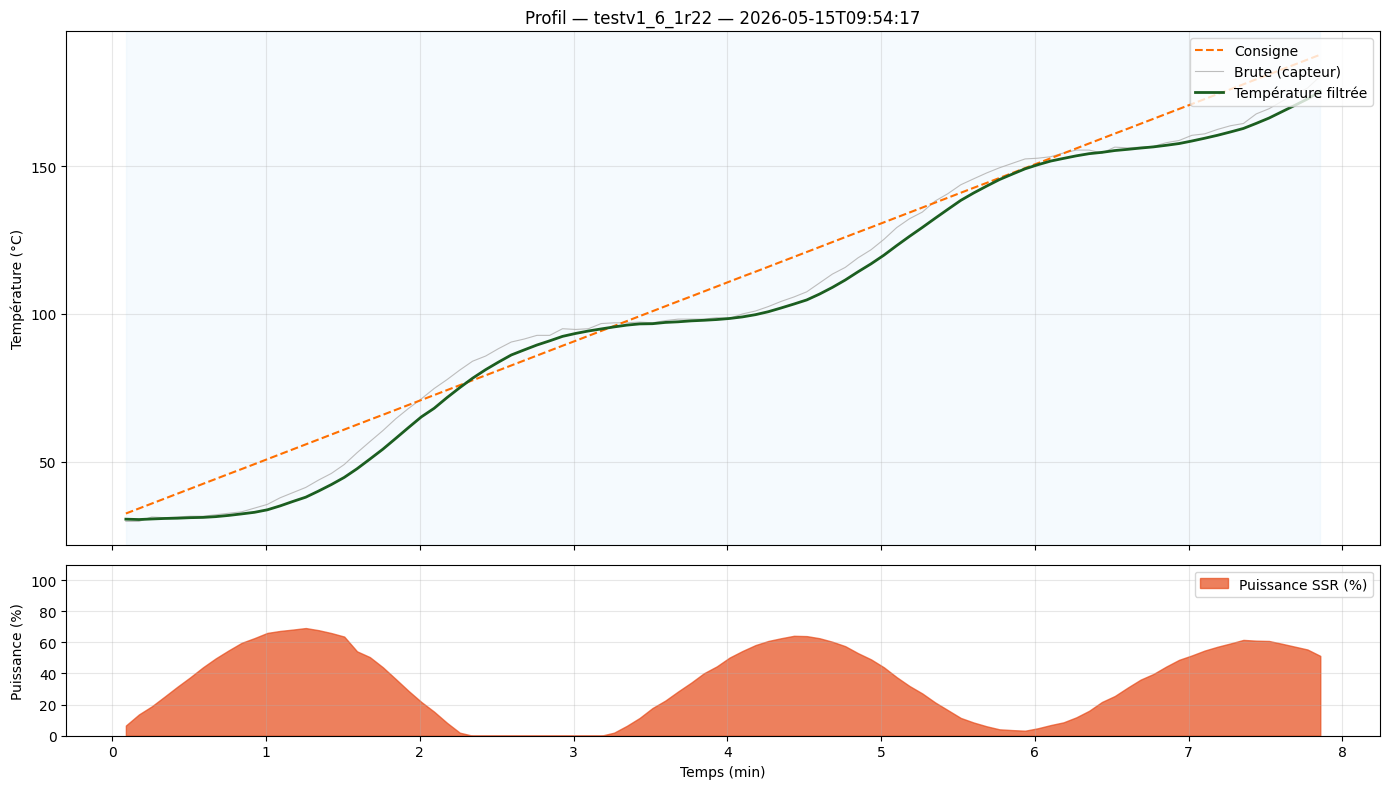

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

elapsed_min = df['elapsed_sec'] / 60

# --- Température ---
ax = axes[0]
ax.plot(elapsed_min, df['target_temp'], '--', color='#FF6F00', lw=1.5,
        label='Consigne', zorder=2)
if 'raw_temp' in df.columns and df['raw_temp'].notna().any():
    ax.plot(elapsed_min, df['raw_temp'], color='#BDBDBD', lw=0.8,
            label='Brute (capteur)', zorder=1)
temp_col = 'filtered_temp' if ('filtered_temp' in df.columns and df['filtered_temp'].notna().any()) else 'current_temp'
ax.plot(elapsed_min, df[temp_col], color='#1B5E20', lw=2,
        label='Température filtrée', zorder=3)

# Zones de phase colorées
phase_colors = {'RAMP': '#E3F2FD', 'HOLD': '#FFF9C4',
                'STABILIZING': '#FCE4EC', 'BOOST': '#FBE9E7', 'IDLE': '#F5F5F5'}
prev_phase, prev_x = None, elapsed_min.iloc[0]
for _, row in df.iterrows():
    x = row['elapsed_sec'] / 60
    p = str(row['phase'])
    if p != prev_phase:
        if prev_phase and prev_phase in phase_colors:
            ax.axvspan(prev_x, x, color=phase_colors[prev_phase], alpha=0.35, zorder=0)
        prev_phase, prev_x = p, x
if prev_phase and prev_phase in phase_colors:
    ax.axvspan(prev_x, elapsed_min.iloc[-1], color=phase_colors[prev_phase], alpha=0.35, zorder=0)

ax.set_ylabel('Température (°C)')
ax.set_title(f"Profil — {meta['program_name']} — {meta['start_datetime']}")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))

# --- PWM SSR ---
ax2 = axes[1]
if 'ssr2_pwm' in df.columns and df['ssr2_pwm'].notna().any():
    ax2.fill_between(elapsed_min, df['ssr2_pwm'] / 1023 * 100,
                     color='#E64A19', alpha=0.7, label='Puissance SSR (%)')
    ax2.set_ylim(0, 110)
    ax2.set_ylabel('Puissance (%)')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
else:
    ax2.set_visible(False)

ax2.set_xlabel('Temps (min)')
plt.tight_layout()
plt.show()

## Photos associées à la session

In [ ]:
import base64
from IPython.display import HTML, display as ipy_display

PHOTOS_BASE = Path('..') / 'photos'
session_dir = PHOTOS_BASE / f'session_{SESSION_ID}'

photos_q = conn.execute(
    'SELECT filename, caption FROM photos WHERE session_id=? ORDER BY id',
    (SESSION_ID,)
).fetchall()

if not photos_q:
    print(f"Aucune photo associée à la session {SESSION_ID}.")
else:
    cards = []
    for filename, caption in photos_q:
        img_path = session_dir / filename
        if not img_path.exists():
            cards.append(f'<div style="color:red;font-family:sans-serif;">Fichier manquant : {filename}</div>')
            continue
        b64  = base64.b64encode(img_path.read_bytes()).decode()
        ext  = img_path.suffix.lower().lstrip('.')
        mime = 'jpeg' if ext in ('jpg', 'jpeg') else ext
        src  = f'data:image/{mime};base64,{b64}'
        lbl  = caption or filename
        cards.append(f'''
        <div style="text-align:center; font-family:sans-serif;">
            <a href="{src}" target="_blank" title="Ouvrir en taille réelle">
                <img src="{src}"
                     style="max-width:340px; max-height:280px; object-fit:contain;
                            border:1px solid #ddd; border-radius:6px;
                            cursor:zoom-in; box-shadow:0 2px 6px rgba(0,0,0,.15);">
            </a>
            <div style="margin-top:6px; font-size:.85em; color:#555; max-width:340px;">{lbl}</div>
        </div>''')

    ipy_display(HTML(f'''
    <div style="display:flex; flex-wrap:wrap; gap:20px; align-items:flex-start; padding:8px 0;">
        {"".join(cards)}
    </div>
    <p style="font-size:.78em; color:#aaa; font-family:sans-serif; margin:4px 0 0 0;">
        Cliquer sur une image pour l'ouvrir en taille réelle dans un nouvel onglet.
    </p>'''))

## Analyse PID (logs maintenance uniquement)

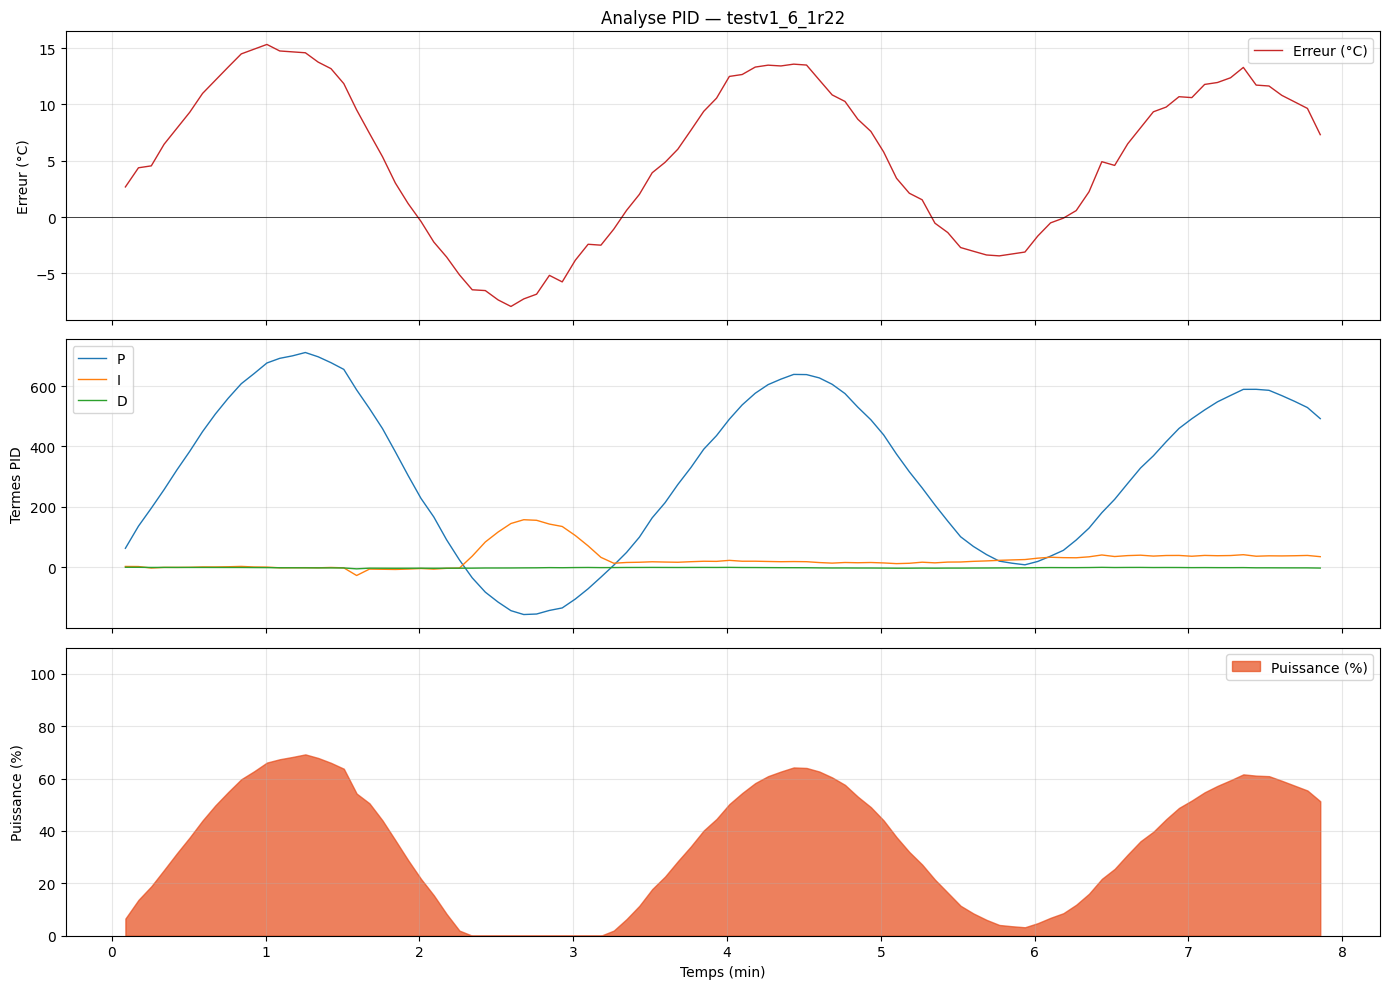

In [6]:
if meta['log_type'] != 'maintenance':
    print("Cette session n'est pas un log maintenance — cellule ignorée.")
else:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    ax = axes[0]
    ax.plot(elapsed_min, df['error'], color='#C62828', lw=1, label='Erreur (°C)')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Erreur (°C)')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(elapsed_min, df['p_term'], label='P', lw=1)
    ax.plot(elapsed_min, df['i_term'], label='I', lw=1)
    ax.plot(elapsed_min, df['d_term'], label='D', lw=1)
    ax.set_ylabel('Termes PID')
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.fill_between(elapsed_min, df['ssr2_pwm'] / 1023 * 100,
                    color='#E64A19', alpha=0.7, label='Puissance (%)')
    ax.set_ylim(0, 110)
    ax.set_ylabel('Puissance (%)')
    ax.set_xlabel('Temps (min)')
    ax.legend(); ax.grid(True, alpha=0.3)

    axes[0].set_title(f'Analyse PID — {meta["program_name"]}')
    plt.tight_layout()
    plt.show()

## Comparaison multi-sessions

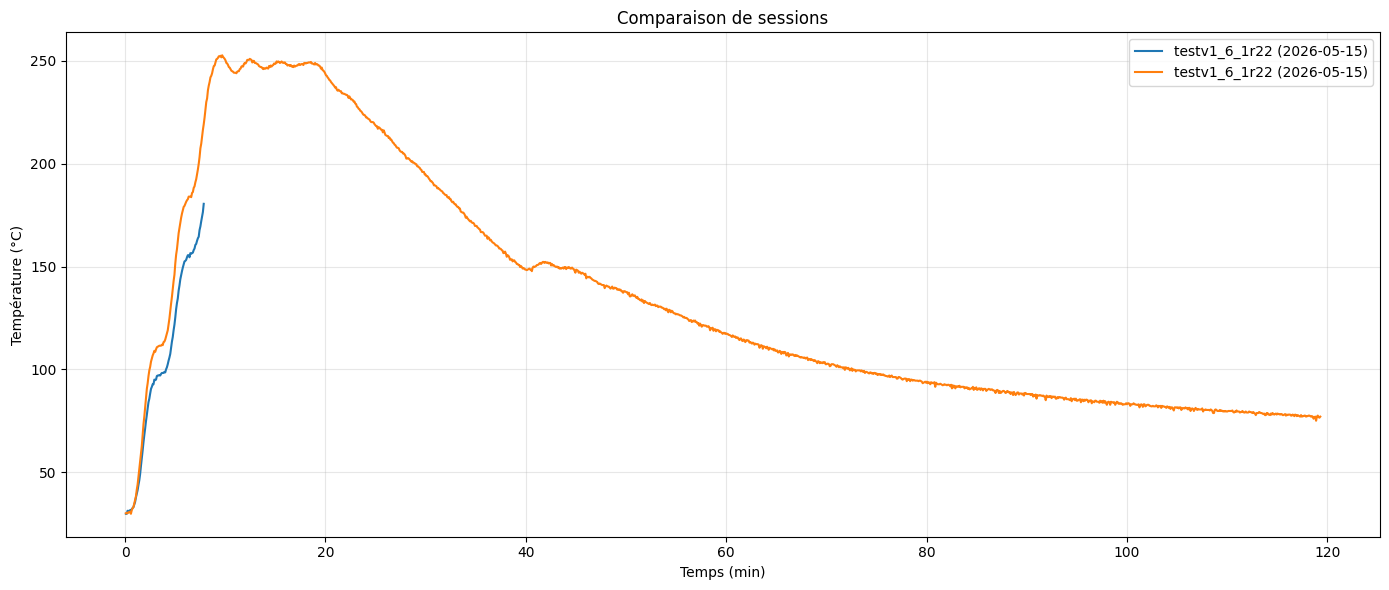

In [8]:
# Comparer plusieurs sessions sur un même graphe
SESSION_IDS = [1,2]  # ← ajouter des IDs ici

fig, ax = plt.subplots(figsize=(14, 6))
for sid in SESSION_IDS:
    m  = dict(conn.execute('SELECT * FROM sessions WHERE id=?', (sid,)).fetchone())
    df2 = pd.read_sql('SELECT elapsed_sec, current_temp FROM datapoints WHERE session_id=? ORDER BY elapsed_sec',
                      conn, params=(sid,))
    label = f"{m['program_name']} ({m['start_datetime'][:10]})"
    ax.plot(df2['elapsed_sec'] / 60, df2['current_temp'], lw=1.5, label=label)

ax.set_xlabel('Temps (min)')
ax.set_ylabel('Température (°C)')
ax.set_title('Comparaison de sessions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()